# Data wrangling

In [1]:
import pandas as pd
import numpy as np

# Import dataset
df = pd.read_csv(r"C:\Users\owner\Downloads\AdmissionsToPublicSectorHospitalsMonthly.csv")

In [2]:
# examine how the dataframe looks like
df.head()

,DataSeries,2026Feb,2026Jan,2025Dec,2025Nov,2025Oct,2025Sep,2025Aug,2025Jul,2025Jun,...,1987Oct,1987Sep,1987Aug,1987Jul,1987Jun,1987May,1987Apr,1987Mar,1987Feb,1987Jan
0,Public Sector Hospital Admissions,42797,49319,48297,46506,49948,47021,46994,48048,44372,...,21313,20682,20714,21291,21096,19602,19797,22173,19074,18822
1,Alexandra Hospital,888,1050,1002,979,1026,927,830,923,905,...,2509,2427,2376,2500,2541,2357,2348,2641,2188,2345
2,Changi General Hospital,4378,5178,5311,4820,5109,4766,4689,5016,4506,...,na,na,na,na,na,na,na,na,na,na
3,Khoo Teck Puat Hospital,3376,3993,3944,3781,4027,3715,3796,3768,3523,...,na,na,na,na,na,na,na,na,na,na
4,National University Hospital,5799,6283,6392,6297,6529,6394,6494,6539,6001,...,2394,2361,2174,2342,2252,2032,2202,2584,1862,1864


In [3]:
# Transpose dataframe
df = df.set_index('DataSeries').T.reset_index()

# Rename columns
df.rename(columns={'index': 'Date'}, inplace=True)
df.columns.name = None

# remove whitespace from column names
df = df.rename(columns=lambda col: col.strip())

# drop this column since it only has missing values
df.drop(columns=['Communicable Disease Centre'], inplace=True)

# convert date column to datetime datatype
df["Date"] = pd.to_datetime(df['Date'], format="%Y%b")

# convert other columns to numeric datatype
hospitals = [c for c in df.columns if c != 'Date']
for col in hospitals:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Make year and month column
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df.sort_values(by='Date', ascending=True, inplace=True)

# make list of acute hospitals (for visualisation later)
acute_hospitals = [
    'Alexandra Hospital', 'Changi General Hospital', 'Khoo Teck Puat Hospital',
    'National University Hospital', 'Ng Teng Fong General Hospital',
    'Sengkang General Hospital', 'Singapore General Hospital',
    'Woodlands Health Campus', 'Tan Tock Seng Hospital', "Kandang Kerbau Women's & Children's Hospital"
]

In [4]:
# examine shape
print('=== SHAPE ===')
print(f'{len(df)} months x {len(hospitals)} series')
print(f'Date range: {df["Date"].min().strftime("%b %Y")} to {df["Date"].max().strftime("%b %Y")}')

=== SHAPE ===
470 months x 14 series
Date range: Jan 1987 to Feb 2026


# Visualise dataset

## Total Admissions

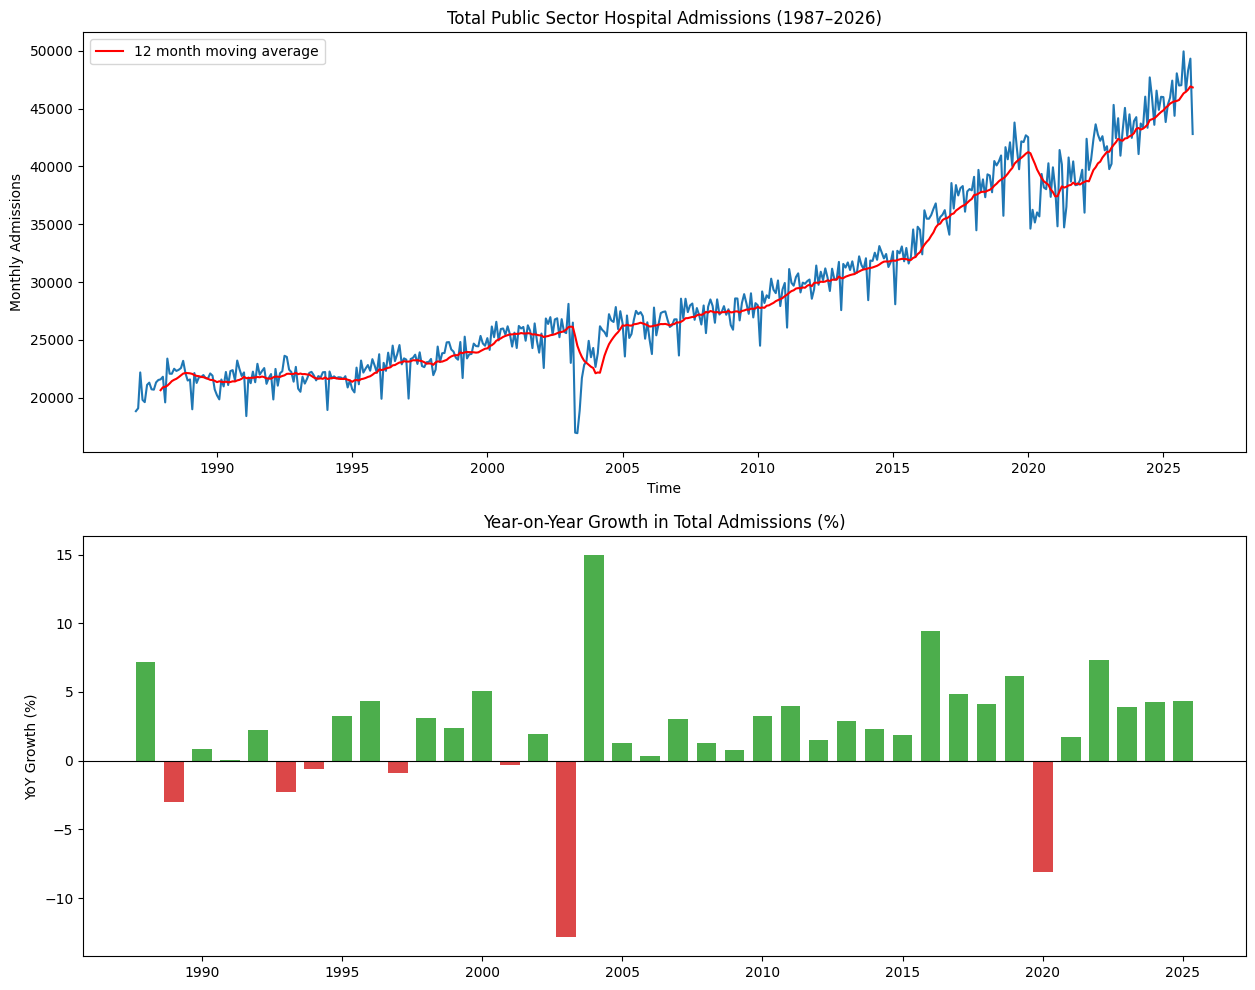

In [5]:
import matplotlib.pyplot as plt

# make moving average
ma = df['Public Sector Hospital Admissions'].rolling(window=12).mean()

# plot monthly admissions
fig, ax = plt.subplots(2, 1, figsize=(15, 12))
ax[0].plot(df['Date'], df['Public Sector Hospital Admissions'])
ax[0].plot(df['Date'], ma, color='r', label='12 month moving average')
ax[0].set_xlabel('Time')
ax[0].set_ylabel('Monthly Admissions')
ax[0].set_title('Total Public Sector Hospital Admissions (1987–2026)')
ax[0].legend(loc=0)

# get yoy % change
annual_total = df[df['Year'] < 2026].groupby('Year')['Public Sector Hospital Admissions'].sum()
yoy = annual_total.pct_change() * 100
yoy_colors = ['#d62728' if v < 0 else '#2ca02c' for v in yoy.values]

# plot yoy % change
ax[1].bar(yoy.index, yoy.values, color=yoy_colors, alpha=0.85, width=0.7)
ax[1].axhline(0, color='black', linewidth=0.8)
ax[1].set_title('Year-on-Year Growth in Total Admissions (%)')
ax[1].set_ylabel('YoY Growth (%)')
plt.show()

### Insights
- **General increase in monthly admissions**

The long-run upward trend from roughly 19,000–23,000 admissions/month in 1987 to 43,000–50,000 by 2026 represents more than a doubling over 38 years. This is strongly tied to Singapore's demographic shift. The resident population aged 65+ doubled from 7% in 1999 to 15.2% in 2020, and is projected to reach 32% by 2060. Crucially, between 2009 and 2014, hospital admissions increased only for one age group: those aged 65 and above, rising from 25.2% of admissions in 2009 to 29% of admissions in 2014. The trend is structural and is projected to continue in the long run.

- **Short term choppiness month to month**

The high month-to-month volatility around the trend line reflects several real-world factors. Infectious disease cycles are a major driver. Being a tropical country, Singapore faces periodic dengue epidemics, seasonal respiratory infections, and flu waves that cause sharp but temporary spikes in admissions.  

- **Notable dips in 2003 and 2020**

The most striking anomaly in the chart is a sharp, sudden dip around 2003, where monthly admissions plunged more than 10% before recovering. This conicided with the 2003 SARS outbreak. Emergency department attendances decreased in line with nationwide public health measures during the SARS outbreak in 2003 before increasing gradually following the lifting of restrictions, albeit not returning immediately to pre-outbreak levels. Fear-driven avoidance of hospitals, suspension of non-essential medical services and quarantine measures all suppressed elective and emergency admissions simultaneously. The rapid V-shaped recovery visible in the charts is consistent with pent-up demand being released post-outbreak.

Around 2020, there also appears to be a visible dip of close to 10%, followed by asteep climb. This mirrors the SARS pattern at a larger scale, as Circuit Breaker measures in 2020 suppressed admissions, and the post-pandemic surge likely reflects accumulated deferred care and the continued ageing of the population.

## Admissions by month (overall)

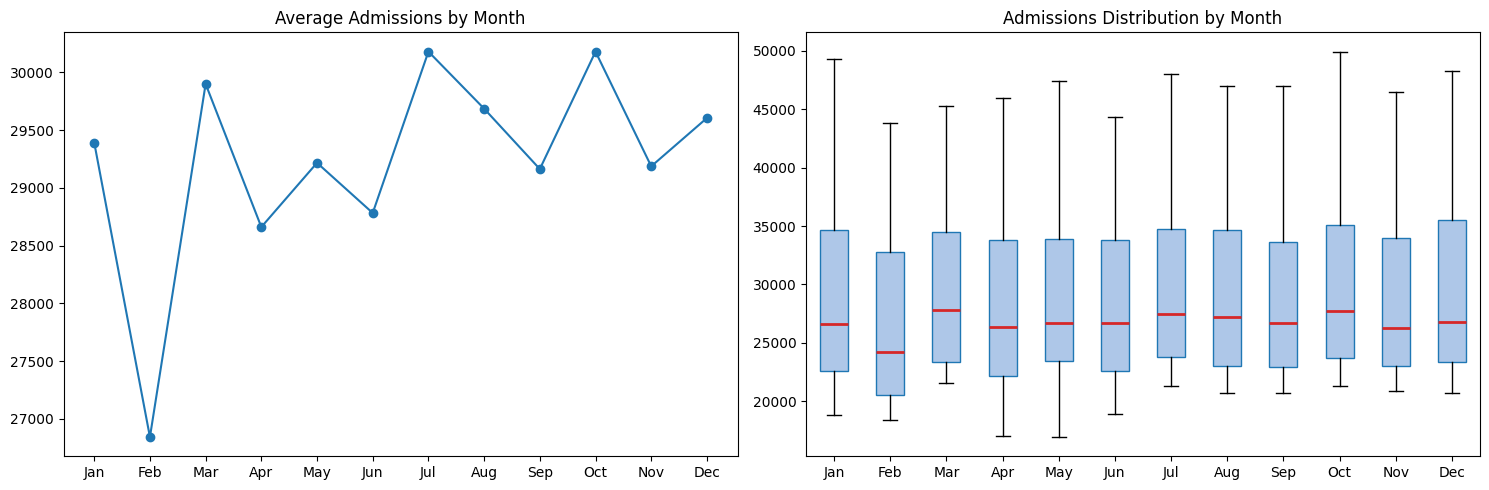

In [6]:
# group data by month
month_grouped = df.iloc[:, 1:].groupby('Month').mean().reset_index()

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# plot line plot
ax[0].plot(month_grouped['Month'], month_grouped['Public Sector Hospital Admissions'], marker='o')
ax[0].set_title('Average Admissions by Month')

# set x ticks
months = pd.to_datetime(pd.Series(range(1, 13)), format='%m').dt.strftime('%b')
ax[0].set_xticks(ticks=range(1, 13))
ax[0].set_xticklabels(months)

# plot boxplot
data_by_month = [df.loc[df['Month']==m, 'Public Sector Hospital Admissions'].dropna().values for m in range(1, 13)]
month_names = pd.date_range('2024', periods=12, freq='MS').strftime('%b').tolist()
ax[1].boxplot(data_by_month, tick_labels=month_names, patch_artist=True,
                boxprops=dict(facecolor='#aec7e8', color='#1f77b4'),
                medianprops=dict(color='#d62728', linewidth=2))
ax[1].set_title('Admissions Distribution by Month')

plt.tight_layout()
plt.show()

### Insights
- **February is a consistent outlier**

February consistently marks the annual low point for hospital discharges, a phenomenon driven by two primary factors. Chronologically, February is the shortest month of the year, and with 2 to 3 fewer days than its neighbors, it naturally records a lower total volume of activity. Furthermore, the dip is further amplified by the cultural significance of Chinese New Year (CNY). In Singapore, there is a widespread preference for patients to be home for the holidays, perhaps leading to a flurry of pre-emptive discharges in late January and a deliberate reduction in elective admissions during the festive period itself. This avoidance of the hospital environment during CNY results in lower admissions in February. The boxplot reinforces this, with February's interquartile range sitting noticeably lower than every other month.

- **Bimodal seasonal peaks**

The left chart shows two clear local peaks in July and October, reflecting a bimodal shape which may indicate a strong epidemiological signal. Influenza A and B viruses circulate year round in Singapore, with bimodal peaks typically observed in May to August and December to March, corresponding approximately with influenza seasons in temperate regions of the Southern and Northern Hemispheres. The July admissions peak aligns well with the Southern Hemisphere winter influenza wave, while the October peak aligns with the early Northern Hemisphere season.

- **Evidence of right skew**

Across all months, the red median line in the boxplot sits noticeably below the midpoint of the IQR box in all months, and the upper whiskers are much longer than the lower whiskers. This indicates positive skewness which could be driven by the surge of admission volumes in recent years.

## Admissions by hospital

In [16]:
from useful_funcs import interactive_multi_lineplot

interactive_multi_lineplot(df, 'Date', acute_hospitals, 'Date', 'Hospital', 'Admissions by Hospital', ma=False, max_vars=len(acute_hospitals))

SelectMultiple(description='Variables:', index=(0,), options=('Alexandra Hospital', 'Changi General Hospital',…

Output()

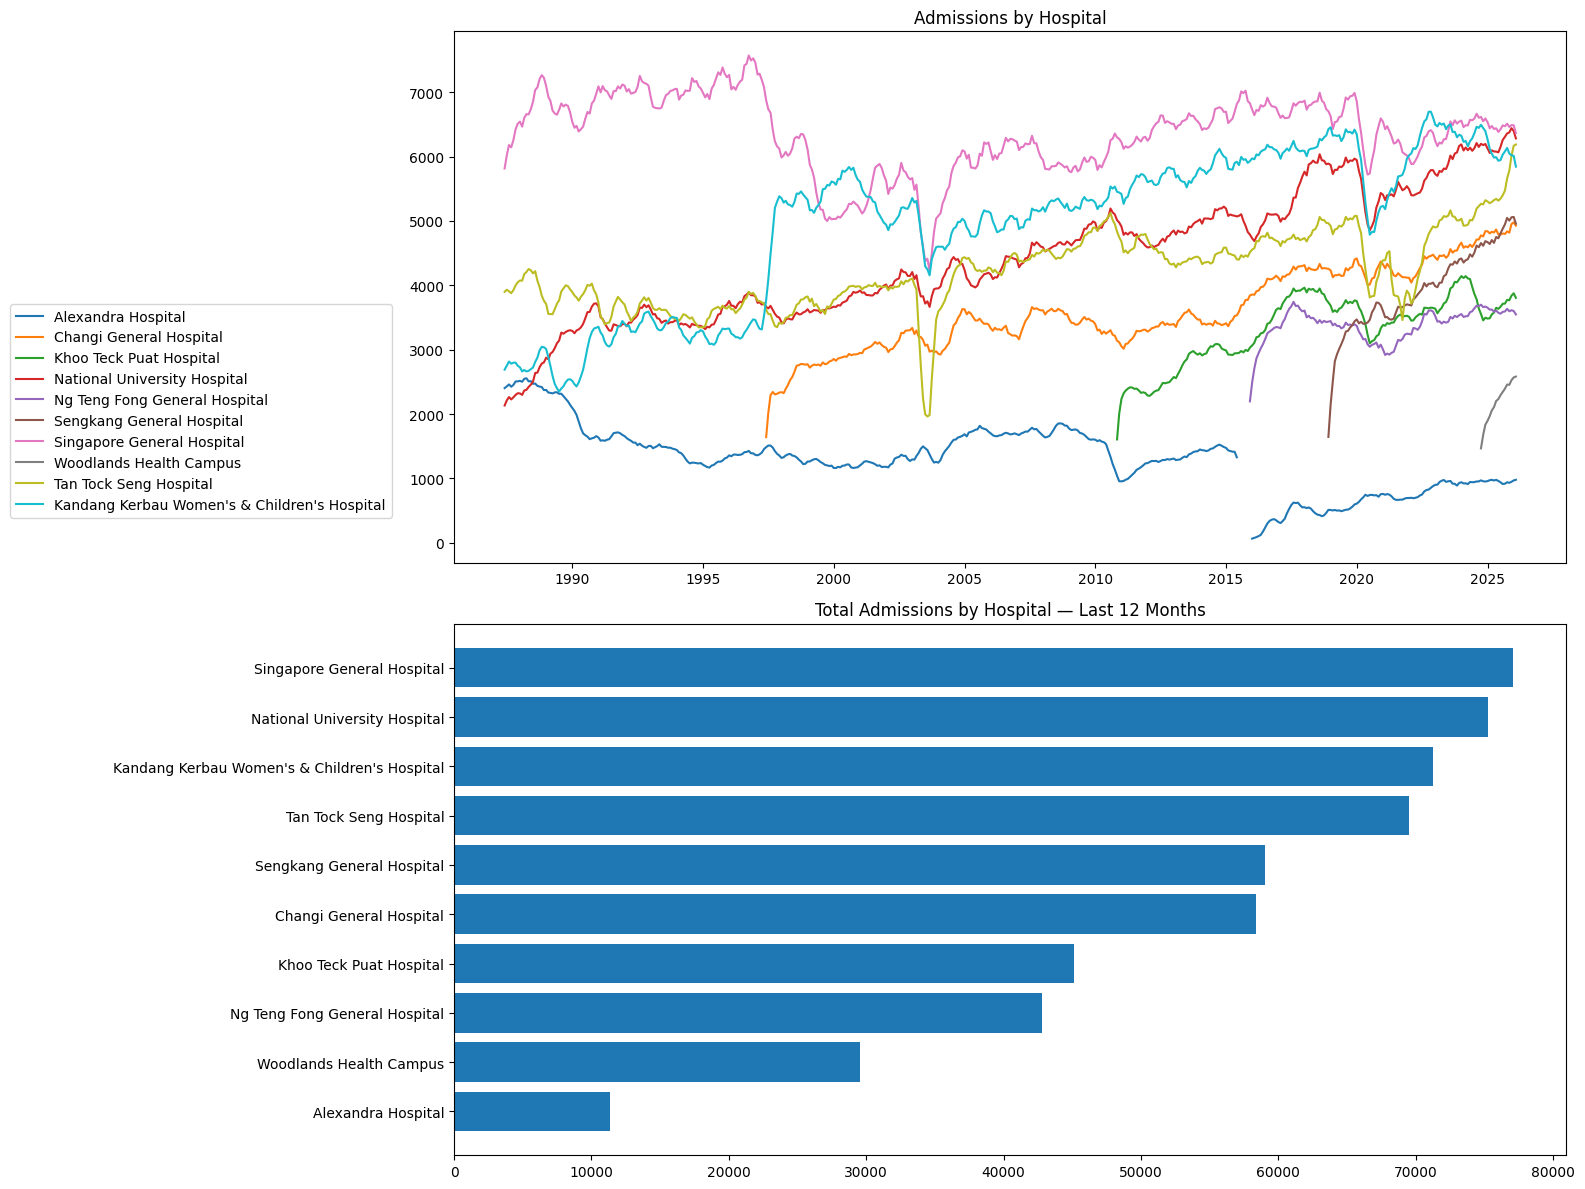

In [7]:
fig, ax = plt.subplots(2, 1, figsize=(16, 12))

# plot line plots for each hospital
for hospital in acute_hospitals:
    ax[0].plot(df['Date'], df[hospital].rolling(window=6).mean(), label=hospital) # used rolling window to smooth out data
ax[0].legend(loc=0, bbox_to_anchor=(-0.05, 0.5))
ax[0].set_title('Admissions by Hospital')

# plot bar chart of total admissions over last 12 months by hospital
latest_12m = df.tail(12)
shares = {h: latest_12m[h].sum() for h in acute_hospitals if latest_12m[h].notna().any()}
shares = pd.Series(shares).sort_values(ascending=True)
ax[1].barh(shares.index, shares.values)
ax[1].set_title('Total Admissions by Hospital — Last 12 Months')

plt.tight_layout()
plt.show()

### Insights
- **Volume dominated by top four hospitals**

The data shows a clear hierarchy in volume, dominated by three major institutions: Singapore General Hospital (SGH), National University Hospital (NUH), Kandang Kerbau Women's & Children's Hospital (KKH) and Tan Tock Seng Hospital (TTSH). These hospitals are the oldest, largest and most established tertiary referral hospitals, managing the highest complexity cases. While Alexandra Hospital is also rather established, it has shifted focus to elective surgeries and specialities rather than handling high-volume, general emergency admissions, resulting in lower volumes.

- **Rise of regional clusters**

Khoo Teck Puat Hospital (KTPH), Ng Teng Fong General Hospital (NTFGH), Sengkang General Hospital (SKH) and Woodlands Health Campus (WHC) have seen sharp rises in admission volumes since inception. This coincided with a flattening of growth in older hospitals, proving that these new regional hubs having been absorbing the growing national demand. The development of these new hospitals play an important role in distributing the healthcare load across hospitals amid an aging population.

## Correlation matrix

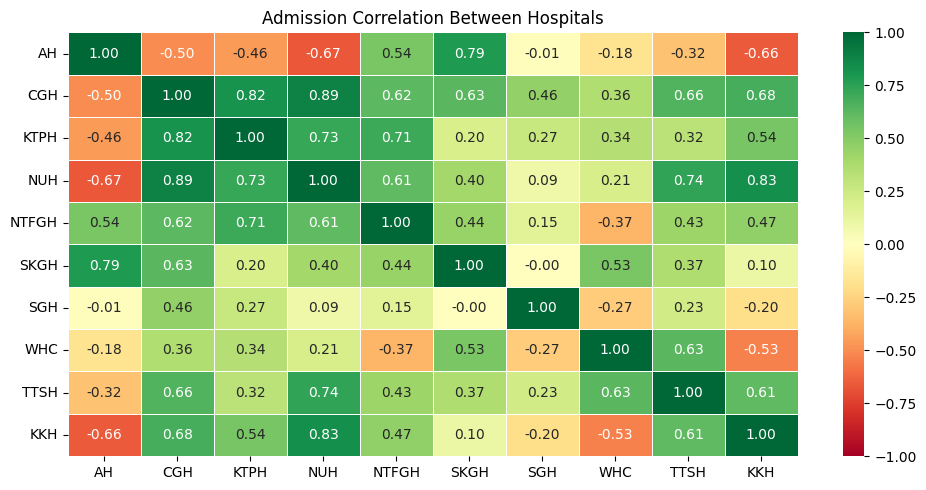

In [8]:
import seaborn as sns

# create correlation matrix
corr = df[acute_hospitals].corr()

# generate plot
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', vmin=-1, vmax=1,
            linewidths=0.5, ax=ax,
            xticklabels=[''.join([word[0] for word in h.split()]) for h in acute_hospitals],
            yticklabels=[''.join([word[0] for word in h.split()]) for h in acute_hospitals])

# since sengkang GH and SGH have the same abbreviation from above, need to change sengkang abbreviation to SK
labels = [item.get_text() for item in ax.get_xticklabels()]
ax.set_title('Admission Correlation Between Hospitals')
labels[5] = 'SKGH'
labels[-1] = 'KKH'
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
plt.tight_layout()
plt.show()

### Insights
- **High correlation between CGH, NUH, KTPH**

The matrix reveals a "tight core" of exceptionally high positive correlations between CGH, NUH, and KTPH, with coefficients ranging from 0.82 to 0.89. Because they serve high-density residential zones across the East, West, and North, their discharge volumes move in near-perfect lockstep. This implies that these institutions are likely simultaneously exposed to the same external stressors such as island-wide flu cycles or environmental haze. This high correlation is a critical warning for system capacity: because they peak at the same time, there is limited opportunity to offload patients to each other during a surge. As such, excess demand from these hospitals can be redirected to other hospitals with lower correlations which likely have more spare capacity when these hospitals are filled.

- **Decoupling from AH, SGH and KKH**

Most hospitals have low or negative correlations with AH, SGH and KKH. 

As the largest and oldest hospital, one might expect SGH to lead the national trend, but the data suggests it is operationally "decoupled" from the regional hospitals. SGH is moving towards a “Hospital Without Walls” approach under Singapore’s capitation-based funding framework. This includes initiatives such as 'Hospital-at-Home' which saved over 8,700 bed days, reducing hospital admissions. While demand remains high, strategies implemented by SGH are likely effective at keeping hospital admissions from growing, as observed in the previous line plots, while newer hospitals face surging demand.

Most public hospitals in Singapore, CGH or KTPH, are designed for high-turnover acute care, meaning they are highly sensitive to seasonal viral spikes like the flu or haze. AH, however, was reimagined as an "Integrated General Hospital" with a heavy emphasis on geriatric care and holistic, long-term recovery. Because elderly patients with multiple chronic conditions have much longer lengths of stay, AH’s discharge cycles may be less sensitive to the rapid, short-term fluctuations of the general population. While other hospitals are clearing out "flu-cycle" patients in synchronized peaks, AH’s steady, slower-paced discharge pattern may appear mathematically uncorrelated or even inverse to those rapid-response facilities.

Similarly, KKH’s low correlations with general hospitals stems from its characteristics as a monospecialist facility for women and children. Admissions are governed by obstetric cycles and pediatric outbreaks, which rarely align with the chronic disease and elderly-driven spikes seen at general hospitals. It also focuses on women and children, a different demographic from most hospitals. Thus, admission volumes in KKH may not follow the overall trends of other hospitals.